C:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.8237 - loss: 0.4947
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8658 - loss: 0.3692
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8772 - loss: 0.3350
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8853 - loss: 0.3102
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8922 - loss: 0.2919
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8955 - loss: 0.2807
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9003 - loss: 0.2655
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9043 - loss: 0.2561
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9071 - loss: 0.2477
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9106 - loss: 0.2386
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8846 - loss: 0.3342

Accuracy: 0.8845999836921692
313/

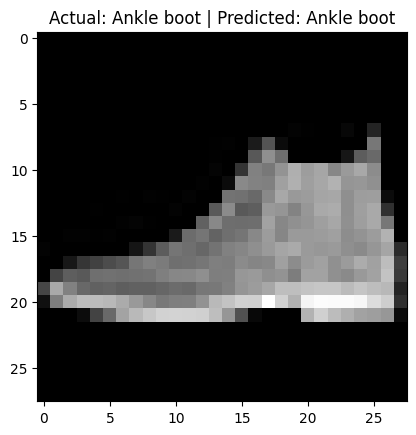

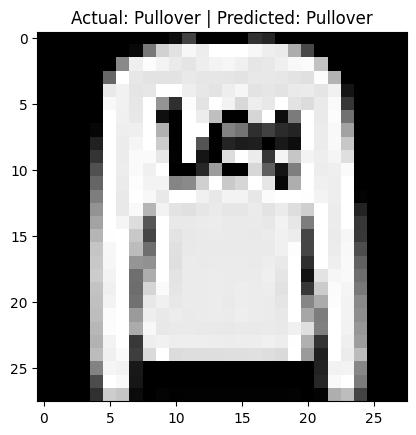

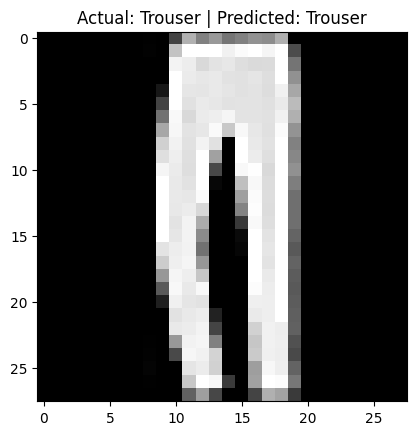

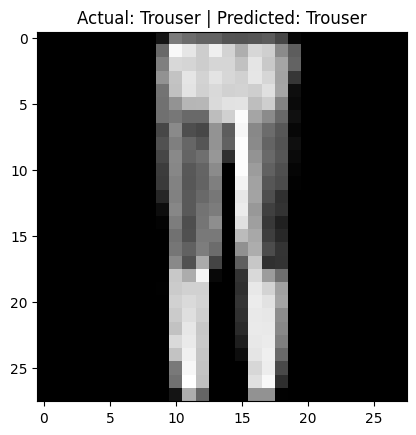

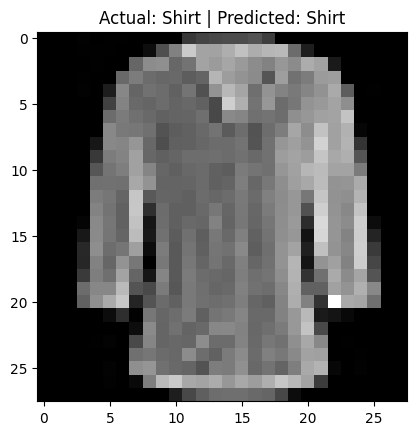

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

# Step 4: Build Deep Neural Network
model = Sequential()

# Convert 2D image into 1D vector
model.add(Flatten(input_shape=(28,28)))

# Hidden Layers
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model.fit(X_train,y_train,epochs=10,batch_size=32,verbose=1)

loss, accuracy = model.evaluate(X_test, y_test)

print("\nAccuracy:", accuracy)

predictions = model.predict(X_test)

fashion_labels = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Step 9: Display Predictions
print("\nActual Category  |  Predicted Category\n")

for i in range(5):

    actual = fashion_labels[y_test[i]]

    predicted = fashion_labels[np.argmax(predictions[i])]

    print(actual, "   |   ", predicted)

for i in range(5):

    plt.imshow(X_test[i], cmap='gray')

    actual = fashion_labels[y_test[i]]

    predicted = fashion_labels[np.argmax(predictions[i])]

    plt.title(f"Actual: {actual} | Predicted: {predicted}")

    plt.show()